In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Učitavanje skupa podataka
housing_data = fetch_openml(name="boston", version=1, as_frame=True)
df_data = housing_data.frame

df_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [2]:
print(df_data.info())
print(df_data.describe())

#Provjera nedostajućih vrijednosti
print("Nedostajuće vrijednosti:\n", df_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB
None
             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.55

In [3]:
X_data = df_data.drop(columns=["MEDV"])
y_data = df_data["MEDV"]
print("Dimenzije X:", X_data.shape)
print("Dimenzije y:", y_data.shape)

Dimenzije X: (506, 13)
Dimenzije y: (506,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=7
)

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)

Train X: (354, 13)
Test X: (152, 13)


In [5]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=7)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=7)

In [6]:
y_predicted = dt_model.predict(X_test)

print("Prvih 10 stvarnih:", y_test.values[:10])
print("Prvih 10 predviđenih:", y_predicted[:10])

Prvih 10 stvarnih: [21.7 18.5 22.2 20.4  8.8  8.3 21.4 23.6 23.5 19. ]
Prvih 10 predviđenih: [20.8742268  20.8742268  20.8742268  20.8742268   9.02083333 27.5
 20.8742268  20.8742268  24.05757576 16.23191489]


In [7]:
rmse_score = np.sqrt(mean_squared_error(y_test, y_predicted))
mae_score = mean_absolute_error(y_test, y_predicted)
r2_score_val = r2_score(y_test, y_predicted)

print("RMSE:", rmse_score)
print("MAE:", mae_score)
print("R2:", r2_score_val)

RMSE: 4.988618796536154
MAE: 3.0002385148499036
R2: 0.662787055449343


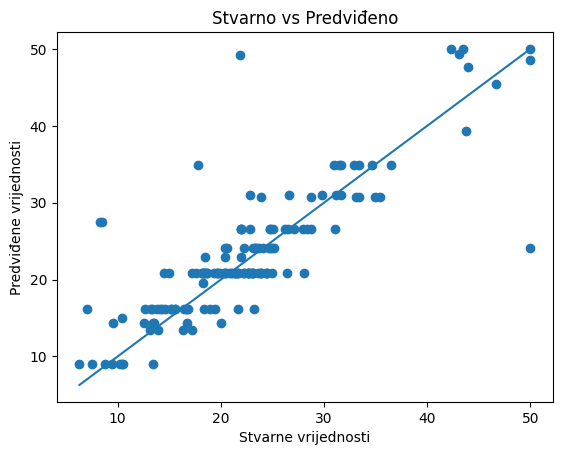

In [8]:
plt.figure()
plt.scatter(y_test, y_predicted)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("Stvarno vs Predviđeno")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

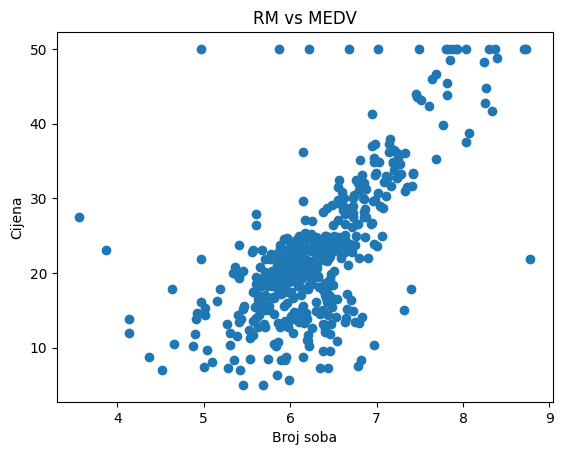

In [9]:
plt.figure()
plt.scatter(df_data["RM"], df_data["MEDV"])
plt.xlabel("Broj soba")
plt.ylabel("Cijena")
plt.title("RM vs MEDV")
plt.show()

In [10]:
importance = pd.DataFrame({
    "feature": X_data.columns,
    "importance": dt_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head())

    feature  importance
5        RM    0.671171
12    LSTAT    0.197193
7       DIS    0.053868
0      CRIM    0.053337
10  PTRATIO    0.007596


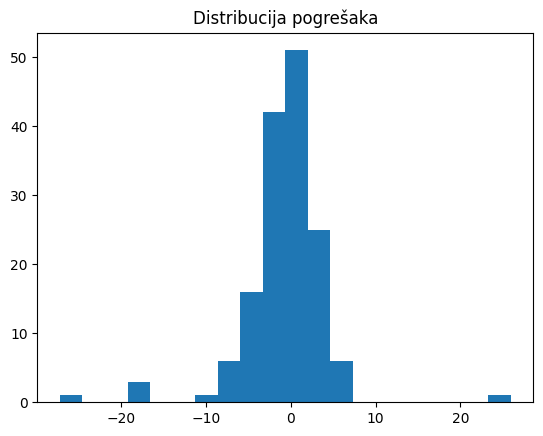

Prosjek: -0.719586955972417
Std dev: 4.952766195253769


In [11]:
errors = y_test - y_predicted

plt.figure()
plt.hist(errors, bins=20)
plt.title("Distribucija pogrešaka")
plt.show()

print("Prosjek:", errors.mean())
print("Std dev:", errors.std())

U ovom zadatku korišten je model Decision Tree Regressor za predviđanje cijena kuća na Boston Housing skupu podataka.

Podaci su podijeljeni na trening i test skup, nakon čega je model treniran i korišten za predviđanje vrijednosti na testnim podacima.
Rezultati pokazuju da model daje solidne predikcije, što se vidi iz vrijednosti RMSE i MAE koje predstavljaju prosječnu pogrešku modela, dok R² pokazuje koliko dobro model objašnjava varijacije u podacima.
Viizualizacijom stvarnih i predviđenih vrijednosti može se uočiti da većina točaka prati dijagonalu, što znači da model u većini slučajeva daje dobre procjene, iako postoje određena odstupanja.
Također, analiza važnosti znacajki pokazuje da neke varijable, poput broja soba (RM), imaju veći utjecaj na cijenu kuće.

Zaključno, model je upotrebljiv, ali bi se mogao dodatno poboljšati podešavanjem parametara kako bi se smanjila pogreška i poboljšala preciznost.